# Componente Avanzado — PCA sobre Perfiles de Agencia
## Reducción de dimensionalidad para comparar agencias por su perfil operativo

**Input**: `outputs/tableau/fact_311.csv` — fact_311 completo (20.8M filas). No se recalcula nada de los notebooks 01-04; este notebook solo agrega `fact_311` a nivel de agencia y aplica PCA sobre ese perfil agregado.

**Objetivo**: construir un perfil numérico por agencia (volumen, velocidad de resolución, distribución horaria y de especialización) y aplicar PCA para visualizar qué agencias comparten un perfil operativo similar — extendiendo a más dimensiones el scatter "volumen vs. tiempo de resolución" del dashboard alpha (`E5 - Relación volumen vs SLA`).

**Documento de referencia**: `docs/reglas-componente-avanzado-pca.md` explica, fuera del código, por qué se eligió PCA y no t-SNE, qué representa cada componente y las limitaciones de aplicar reducción de dimensionalidad sobre una muestra de 20 agencias.

---
## 0. Setup

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from _shared import ensure_output_dir, save_for_tableau_final

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42

WEEK       = 'week-06-311'
INPUT_PATH = ROOT / 'outputs' / 'tableau' / 'fact_311.csv'
OUTPUT_DIR = ensure_output_dir(WEEK)

print(f'Input:  {INPUT_PATH}  ->  existe: {INPUT_PATH.exists()}')
print(f'Output: {OUTPUT_DIR}')

Input:  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\tableau\fact_311.csv  ->  existe: True
Output: C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-06-311


---
## 1. Por qué PCA y no t-SNE

`fact_311.csv` es transaccional (un registro por queja) — no tiene una representación vectorial rica a nivel de fila que justifique aplicar t-SNE directamente. La alternativa correcta, prevista en el enunciado del curso ("PCA sobre variables derivadas"), es construir un **perfil agregado por agencia** y aplicar la técnica sobre ese perfil.

Con esa agregación quedan **~20 agencias** (una fila por agencia) — una muestra demasiado pequeña para que t-SNE aporte algo: t-SNE está pensado para revelar estructura no lineal en cientos o miles de puntos, y con tan pocos puntos su resultado es inestable y difícil de interpretar de forma reproducible. PCA, en cambio, da ejes lineales interpretables (se puede leer literalmente qué variables originales pesan en cada componente) y es la herramienta correcta para este tamaño de muestra. El detalle de esta decisión y las alternativas descartadas están en `docs/reglas-componente-avanzado-pca.md`.

---
## 2. Carga de datos — solo las columnas necesarias

`fact_311.csv` pesa ~3.6 GB (20.8M filas × 17 columnas). Para construir el perfil por agencia solo se necesitan 6 columnas, así que se cargan con `usecols` y `dtype='category'` en las columnas de baja cardinalidad — mismo criterio de memoria que usaron los notebooks 02-04.

In [2]:
USECOLS = ['Unique Key', 'Agency', 'Borough', 'problem_family', 'hour_of_day', 'resolution_hours']
CATEGORY_COLS = ['Agency', 'Borough', 'problem_family']

fact = pd.read_csv(INPUT_PATH, usecols=USECOLS, dtype={col: 'category' for col in CATEGORY_COLS})

print(f'fact_311 (columnas reducidas): {fact.shape}')
fact.head(3)

fact_311 (columnas reducidas): (20855981, 6)


,Unique Key,Borough,Agency,hour_of_day,resolution_hours,problem_family
0,68688622,Queens,NYPD,2,NaN,Ruido
1,68687425,Queens,OOS,2,NaN,Otros
2,68694741,Brooklyn,NYPD,2,NaN,Tráfico / Estacionamiento


---
## 3. Construcción del perfil numérico por agencia

Nueve variables numéricas por agencia — volumen, velocidad de resolución (promedio y mediana, igual que en el notebook 01 se prefirió mediana por el sesgo de la distribución), distribución en 4 rangos de SLA, patrón horario y grado de especialización:

| Variable | Qué mide | Cómo se calcula |
|---|---|---|
| `volumen_total` | Tamaño de la agencia | `COUNT` de quejas |
| `horas_promedio` | Velocidad de resolución (promedio) | `AVG(resolution_hours)` sobre quejas resueltas |
| `horas_mediana` | Velocidad de resolución (típica) | `MEDIAN(resolution_hours)` sobre quejas resueltas |
| `pct_horario_nocturno` | Patrón horario | % de quejas abiertas entre 20:00-06:59 |
| `pct_top_familia` | Especialización | % de sus quejas en su `problem_family` más frecuente |
| `pct_menos_24h` | SLA — resolución same-day | % resuelto en ≤ 24h |
| `pct_1_3d` | SLA — resolución en 1-3 días | % resuelto en (24h, 72h] |
| `pct_3_7d` | SLA — resolución en 3-7 días | % resuelto en (72h, 168h] |
| `pct_mas_7d` | SLA — rezago crítico | % resuelto en > 168h |

**Variable evaluada y descartada**: `n_boroughs_activos` (cantidad de boroughs donde opera cada agencia). Se calculó pero resultó constante (todas las agencias operan en los 5 boroughs) — varianza cero, no aporta nada a un PCA. Se documenta el descarte en `docs/reglas-componente-avanzado-pca.md` en vez de eliminarlo silenciosamente del código.

In [3]:
volumen_total = fact.groupby('Agency', observed=True)['Unique Key'].count().rename('volumen_total')

nocturno_mask = fact['hour_of_day'].between(20, 23) | fact['hour_of_day'].between(0, 6)
pct_horario_nocturno = (
    fact.assign(nocturno=nocturno_mask)
    .groupby('Agency', observed=True)['nocturno']
    .mean() * 100
).rename('pct_horario_nocturno')

fam_counts = fact.groupby(['Agency', 'problem_family'], observed=True)['Unique Key'].count()
pct_top_familia = (
    fam_counts.groupby(level=0, observed=True).apply(lambda s: s.max() / s.sum() * 100)
).rename('pct_top_familia')

print('volumen_total, pct_horario_nocturno y pct_top_familia calculados.')

volumen_total, pct_horario_nocturno y pct_top_familia calculados.


In [4]:
resueltos = fact[fact['resolution_hours'].notna()]

horas_promedio = resueltos.groupby('Agency', observed=True)['resolution_hours'].mean().rename('horas_promedio')
horas_mediana  = resueltos.groupby('Agency', observed=True)['resolution_hours'].median().rename('horas_mediana')

def pct_en_rango(serie, lo, hi):
    if hi is None:
        return (serie > lo).mean() * 100
    return ((serie > lo) & (serie <= hi)).mean() * 100

sla_rows = []
for agencia, g in resueltos.groupby('Agency', observed=True):
    sla_rows.append({
        'Agency': agencia,
        'n_resueltos': len(g),
        'pct_menos_24h': (g['resolution_hours'] <= 24).mean() * 100,
        'pct_1_3d': pct_en_rango(g['resolution_hours'], 24, 72),
        'pct_3_7d': pct_en_rango(g['resolution_hours'], 72, 168),
        'pct_mas_7d': pct_en_rango(g['resolution_hours'], 168, None),
    })
sla_df = pd.DataFrame(sla_rows).set_index('Agency')

perfil_agencia = (
    pd.concat([volumen_total, horas_promedio, horas_mediana, pct_horario_nocturno, pct_top_familia, sla_df], axis=1)
    .reset_index()
    .rename(columns={'index': 'Agency'})
)

print(f'perfil_agencia: {perfil_agencia.shape}')
perfil_agencia.sort_values('volumen_total', ascending=False).round(2)

perfil_agencia: (21, 11)


,Agency,volumen_total,horas_promedio,horas_mediana,pct_horario_nocturno,pct_top_familia,n_resueltos,pct_menos_24h,pct_1_3d,pct_3_7d,pct_mas_7d
11,NYPD,9067475,3.78,0.90,49.44,47.10,9066331.0,98.99,0.64,0.16,0.21
9,HPD,4185487,384.25,98.71,22.50,55.59,4112635.0,12.00,28.91,21.14,37.95
7,DSNY,2380782,231.98,52.42,14.45,77.44,2361414.0,23.52,36.65,23.90,15.93
5,DOT,1389322,322.05,41.41,18.33,70.50,1313555.0,42.75,16.13,14.47,26.65
1,DEP,1089443,109.20,20.92,23.79,55.66,1074231.0,54.51,19.39,13.39,12.71
6,DPR,768942,4444.43,540.39,12.15,75.04,677435.0,17.36,8.95,9.61,64.08
3,DOB,605950,1242.54,229.26,15.96,99.98,605767.0,27.51,10.02,9.16,53.31
4,DOHMH,502984,3677.56,20.46,26.18,51.85,465972.0,51.42,9.38,4.22,34.98
2,DHS,273369,68.68,5.63,27.16,100.00,218035.0,76.06,9.54,6.16,8.24
14,TLC,185753,1517.64,1139.74,25.83,100.00,146909.0,13.48,9.61,5.64,71.27


### 3.1 Filtro — excluir agencias con muestra insuficiente

**Decisión**: `MIN_RESUELTOS = 500`. Se excluyen agencias con menos de 500 quejas resueltas porque sus porcentajes (`pct_menos_24h`, etc.) se calculan sobre muy pocos casos y no son estadísticamente estables — un único caso puede mover el porcentaje en varios puntos.

**Alternativa descartada**: no filtrar. Se descartó porque `3-1-1` (la agencia "311" mal etiquetada dentro de `Agency`, no confundir con el sistema 311 completo) tiene **1 sola fila** en todo el dataset — un caso así distorsionaría el PCA sin aportar información real sobre un perfil operativo.

In [5]:
MIN_RESUELTOS = 500
antes = len(perfil_agencia)
perfil_filtrado = perfil_agencia[perfil_agencia['n_resueltos'] >= MIN_RESUELTOS].reset_index(drop=True)

excluidas = set(perfil_agencia['Agency']) - set(perfil_filtrado['Agency'])
print(f'Agencias antes del filtro: {antes}')
print(f'Agencias después del filtro (n_resueltos >= {MIN_RESUELTOS}): {len(perfil_filtrado)}')
print(f'Excluidas: {excluidas}')

Agencias antes del filtro: 21
Agencias después del filtro (n_resueltos >= 500): 20
Excluidas: {'3-1-1'}


---
## 4. Estandarización y PCA

`volumen_total` (cientos a millones) y los `pct_*` (0-100) tienen escalas muy distintas — sin estandarizar, PCA quedaría dominado por `volumen_total` solo por su magnitud, no porque sea la variable más informativa. Se aplica `StandardScaler` (media 0, desviación estándar 1) antes de PCA, igual que exige la técnica.

In [6]:
FEATURES = [
    'volumen_total', 'horas_promedio', 'horas_mediana', 'pct_horario_nocturno',
    'pct_top_familia', 'pct_menos_24h', 'pct_1_3d', 'pct_3_7d', 'pct_mas_7d',
]
print(f'{len(FEATURES)} variables numéricas usadas en el PCA:')
print(FEATURES)

X = perfil_filtrado[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nMedia por variable tras estandarizar (debe ser ~0): {X_scaled.mean(axis=0).round(6)}')
print(f'Desv. estándar por variable tras estandarizar (debe ser ~1): {X_scaled.std(axis=0).round(6)}')

9 variables numéricas usadas en el PCA:
['volumen_total', 'horas_promedio', 'horas_mediana', 'pct_horario_nocturno', 'pct_top_familia', 'pct_menos_24h', 'pct_1_3d', 'pct_3_7d', 'pct_mas_7d']

Media por variable tras estandarizar (debe ser ~0): [-0.  0.  0. -0. -0.  0. -0.  0. -0.]
Desv. estándar por variable tras estandarizar (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 4.1 Varianza explicada — cuántos componentes tienen sentido

Antes de quedarnos con 2 componentes (los que se pueden graficar), miramos cuánta varianza explica cada uno con todas las 9 variables.

componente  varianza_pct  varianza_acumulada_pct
       PC1          43.9                    43.9
       PC2          30.2                    74.0
       PC3          10.8                    84.8
       PC4           6.9                    91.8
       PC5           3.8                    95.6
       PC6           2.1                    97.7
       PC7           1.5                    99.2
       PC8           0.8                   100.0
       PC9           0.0                   100.0


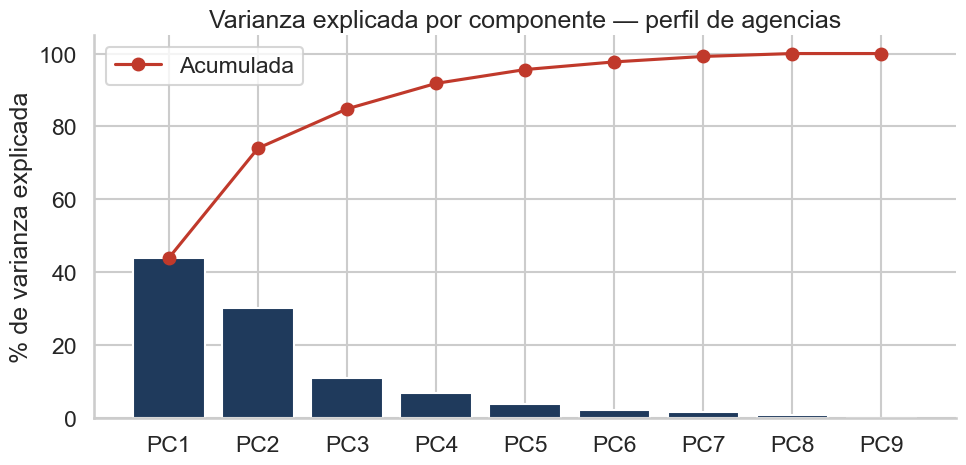

In [7]:
pca_full = PCA(n_components=len(FEATURES), random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

varianza_pct = pca_full.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_pct)

pca_varianza_explicada = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(FEATURES))],
    'varianza_pct': varianza_pct.round(1),
    'varianza_acumulada_pct': varianza_acumulada.round(1),
})
print(pca_varianza_explicada.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pca_varianza_explicada['componente'], pca_varianza_explicada['varianza_pct'], color='#1F3A5C')
ax.plot(pca_varianza_explicada['componente'], pca_varianza_explicada['varianza_acumulada_pct'],
        color='#C0392B', marker='o', label='Acumulada')
ax.set_ylabel('% de varianza explicada')
ax.set_title('Varianza explicada por componente — perfil de agencias')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_varianza_explicada.png', dpi=150, bbox_inches='tight')
plt.show()

**Decisión**: se usan **2 componentes** para la visualización, que explican en conjunto la varianza acumulada mostrada arriba (ver también `docs/reglas-componente-avanzado-pca.md` con la cifra final documentada). Es suficiente para una proyección 2D razonablemente fiel al perfil de 9 variables, y es el máximo que se puede graficar en un scatter simple para Tableau.

### 4.2 Proyección a 2 componentes e interpretación de los loadings

Los *loadings* dicen qué variables originales pesan más en cada componente — es lo que permite explicar en palabras qué significa "estar a la derecha" o "estar arriba" en el scatter, en vez de dejar los ejes como números abstractos.

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes = pca.fit_transform(X_scaled)

perfil_filtrado['PC1'] = componentes[:, 0].round(3)
perfil_filtrado['PC2'] = componentes[:, 1].round(3)

pca_loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['PC1', 'PC2']).round(3)
pca_loadings.index.name = 'variable'
print('Loadings (peso de cada variable en cada componente):')
print(pca_loadings.to_string())

print('\nVariables más influyentes en PC1 (por valor absoluto):')
print(pca_loadings['PC1'].abs().sort_values(ascending=False).round(3).to_string())
print('\nVariables más influyentes en PC2 (por valor absoluto):')
print(pca_loadings['PC2'].abs().sort_values(ascending=False).round(3).to_string())

Loadings (peso de cada variable en cada componente):
                        PC1    PC2
variable                          
volumen_total        -0.326 -0.301
horas_promedio        0.318 -0.202
horas_mediana         0.426 -0.207
pct_horario_nocturno -0.229 -0.479
pct_top_familia       0.327  0.182
pct_menos_24h        -0.397 -0.265
pct_1_3d             -0.214  0.479
pct_3_7d             -0.160  0.508
pct_mas_7d            0.471 -0.077

Variables más influyentes en PC1 (por valor absoluto):
variable
pct_mas_7d              0.471
horas_mediana           0.426
pct_menos_24h           0.397
pct_top_familia         0.327
volumen_total           0.326
horas_promedio          0.318
pct_horario_nocturno    0.229
pct_1_3d                0.214
pct_3_7d                0.160

Variables más influyentes en PC2 (por valor absoluto):
variable
pct_3_7d                0.508
pct_1_3d                0.479
pct_horario_nocturno    0.479
volumen_total           0.301
pct_menos_24h           0.265
horas_median

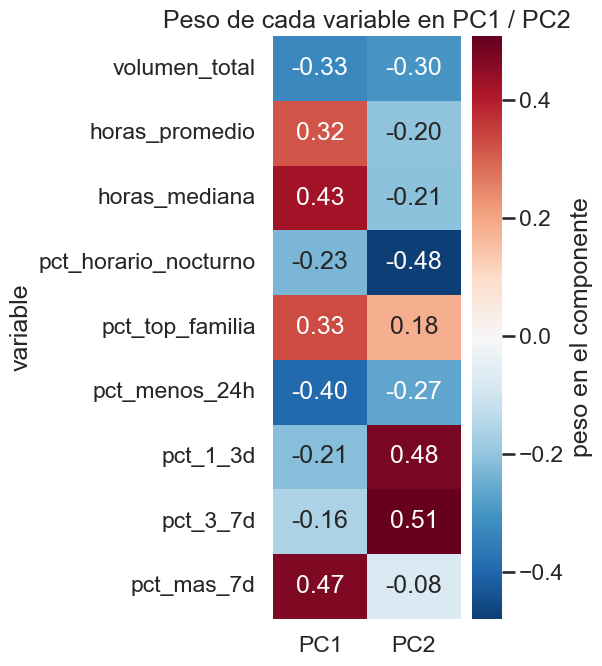

In [9]:
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(pca_loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'peso en el componente'}, ax=ax)
ax.set_title('Peso de cada variable en PC1 / PC2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación (resultado real de esta ejecución, ver cifras arriba):**

- **PC1 — eje de eficiencia de resolución.** Las variables con mayor peso son `pct_mas_7d`, `horas_mediana` y `pct_menos_24h` (con signos opuestos entre sí), junto con `volumen_total` y `pct_top_familia`. Agencias con PC1 muy negativo combinan alto volumen y resolución rápida (caso extremo: NYPD). Agencias con PC1 muy positivo combinan bajo `pct_menos_24h`, alta `pct_mas_7d` y alta especialización (caso extremo: EDC, OOS).
- **PC2 — eje de forma de la distribución y patrón horario.** Dominado por `pct_3_7d`, `pct_1_3d` (positivos) y `pct_horario_nocturno` junto con `volumen_total` (negativos). Separa agencias cuya resolución se concentra en los rangos intermedios (1-7 días) de agencias con un patrón horario nocturno más marcado o tiempos más extremos (muy rápidos o muy lentos, con poco "término medio").

Esto conecta directamente con el insight ya existente en el dashboard alpha ("EDC tarda 27x más que el promedio") — PC1 muestra que esa lentitud de EDC no es un caso aislado en una sola métrica, sino un patrón que se sostiene across 5 de las 9 variables del perfil.

---
## 5. Clustering complementario (K-Means)

Colorear el scatter de PCA solo por una métrica continua (p. ej. `pct_mas_7d`) ya es útil, pero un clustering sobre las mismas variables estandarizadas agrupa a las agencias en perfiles discretos y nombrables — más fácil de comunicar en el dashboard que un degradado de color.

Se prueban varios valores de *k* y se elige por `silhouette_score` (qué tan bien separados quedan los grupos) **y** por interpretabilidad — con solo 20 agencias, un *k* alto produce grupos de 1-2 agencias que no aportan una narrativa clara.

In [10]:
silhouette_por_k = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_por_k.append({'k': k, 'silhouette': round(score, 3)})

print(pd.DataFrame(silhouette_por_k).to_string(index=False))

 k  silhouette
 2       0.266
 3       0.277
 4       0.234
 5       0.284


**Decisión**: `k = 3`. El silhouette de k=3 está prácticamente empatado con el mejor valor de la tabla (ver salida arriba), y a diferencia de valores de *k* más altos produce 3 grupos de tamaño razonable y fáciles de nombrar (rápidas / intermedias / rezago crónico) en vez de fragmentar 20 agencias en grupos de 1-2. El detalle de esta decisión está en `docs/reglas-componente-avanzado-pca.md`.

In [11]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
perfil_filtrado['cluster_id'] = kmeans.labels_

medias_cluster = (
    perfil_filtrado.groupby('cluster_id')[['horas_mediana', 'pct_mas_7d', 'volumen_total']]
    .mean()
    .sort_values('horas_mediana')
)
print('Medias por cluster (para nombrarlos por velocidad de resolución):')
print(medias_cluster.round(1).to_string())

# Se nombran los clusters ordenando por horas_mediana ascendente: el más rápido,
# el intermedio y el de rezago crónico — en vez de dejar IDs numéricos sin significado.
orden_clusters = medias_cluster.index.tolist()
nombres_cluster = {
    orden_clusters[0]: 'Rápida (alto volumen)',
    orden_clusters[1]: 'Intermedia',
    orden_clusters[2]: 'Rezago crónico',
}
perfil_filtrado['cluster'] = perfil_filtrado['cluster_id'].map(nombres_cluster)

resumen_cluster = (
    perfil_filtrado.groupby('cluster')
    .agg(n_agencias=('Agency', 'count'), volumen_total=('volumen_total', 'sum'),
         horas_mediana_prom=('horas_mediana', 'mean'), pct_mas_7d_prom=('pct_mas_7d', 'mean'))
    .round(1)
)
resumen_cluster['pct_del_volumen_total'] = (
    resumen_cluster['volumen_total'] / perfil_filtrado['volumen_total'].sum() * 100
).round(1)
print('\nResumen por cluster:')
print(resumen_cluster.to_string())

print('\nAgencias en el cluster "Rezago crónico":')
print(perfil_filtrado.loc[perfil_filtrado['cluster'] == 'Rezago crónico', 'Agency'].tolist())

Medias por cluster (para nombrarlos por velocidad de resolución):
            horas_mediana  pct_mas_7d  volumen_total
cluster_id                                          
0                     0.9         0.2      9067475.0
2                    39.4        23.0      1003771.8
1                   615.7        71.3       194531.9

Resumen por cluster:
                       n_agencias  volumen_total  horas_mediana_prom  pct_mas_7d_prom  pct_del_volumen_total
cluster                                                                                                     
Intermedia                     10       10037718                39.4             23.0                   48.1
Rezago crónico                  9        1750787               615.7             71.3                    8.4
Rápida (alto volumen)           1        9067475                 0.9              0.2                   43.5

Agencias en el cluster "Rezago crónico":
['DOB', 'DPR', 'EDC', 'OOS', 'OTI', 'TLC', 'DOE', 'DFTA', 'D

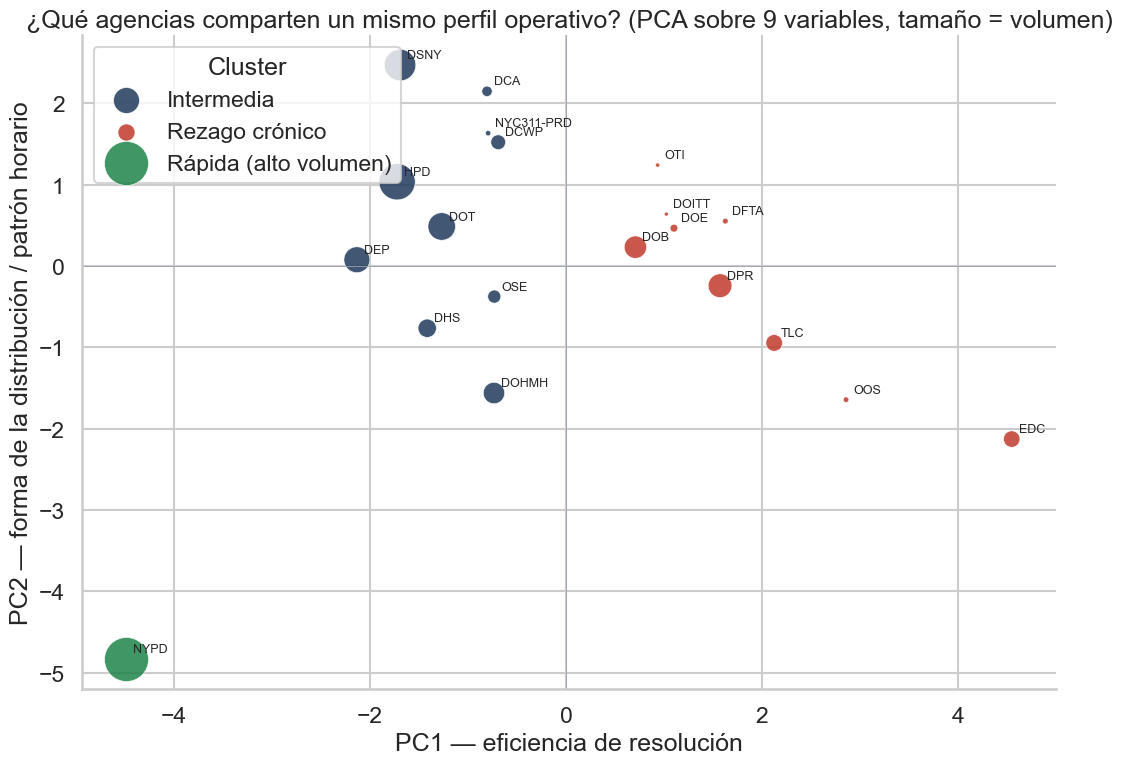

In [12]:
fig, ax = plt.subplots(figsize=(11, 8))
palette = {'Rápida (alto volumen)': '#1E8449', 'Intermedia': '#1F3A5C', 'Rezago crónico': '#C0392B'}

for cluster_name, g in perfil_filtrado.groupby('cluster'):
    ax.scatter(g['PC1'], g['PC2'], s=g['volumen_total'] ** 0.5 / 3,
               color=palette[cluster_name], label=cluster_name, alpha=0.85, edgecolor='white', linewidth=0.5)

for _, row in perfil_filtrado.iterrows():
    ax.annotate(row['Agency'], (row['PC1'], row['PC2']), fontsize=9,
                xytext=(5, 5), textcoords='offset points')

ax.axhline(0, color='#9CA3AF', linewidth=0.6)
ax.axvline(0, color='#9CA3AF', linewidth=0.6)
ax.set_xlabel('PC1 — eficiencia de resolución')
ax.set_ylabel('PC2 — forma de la distribución / patrón horario')
ax.set_title('¿Qué agencias comparten un mismo perfil operativo? (PCA sobre 9 variables, tamaño = volumen)')
ax.legend(title='Cluster', loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_scatter_agencias.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Validación

Antes de exportar, se verifica que el filtro no haya dejado agencias sin perfil completo, que la estandarización se aplicó correctamente y que los 3 clusters cubren exactamente las agencias filtradas (sin perder ni duplicar ninguna).

In [13]:
validation = pd.DataFrame([
    {'check': 'agencias_antes_del_filtro',        'value': antes},
    {'check': 'agencias_despues_del_filtro',      'value': len(perfil_filtrado)},
    {'check': 'agencias_excluidas',               'value': str(excluidas)},
    {'check': 'variables_en_pca',                 'value': len(FEATURES)},
    {'check': 'sin_nulos_en_features',            'value': bool(perfil_filtrado[FEATURES].isna().sum().sum() == 0)},
    {'check': 'media_escalada_aprox_0',           'value': bool(np.allclose(X_scaled.mean(axis=0), 0, atol=1e-6))},
    {'check': 'std_escalada_aprox_1',             'value': bool(np.allclose(X_scaled.std(axis=0), 1, atol=1e-6))},
    {'check': 'varianza_explicada_2_componentes', 'value': f'{varianza_acumulada[1]:.1f}%'},
    {'check': 'n_clusters',                       'value': perfil_filtrado['cluster'].nunique()},
    {'check': 'suma_agencias_por_cluster_ok',     'value': bool(perfil_filtrado.groupby('cluster')['Agency'].count().sum() == len(perfil_filtrado))},
])
print(validation.to_string(index=False))

assert perfil_filtrado[FEATURES].isna().sum().sum() == 0, 'ERROR: quedaron nulos en las variables del PCA'
assert perfil_filtrado.groupby('cluster')['Agency'].count().sum() == len(perfil_filtrado), 'ERROR: el clustering no cubre todas las agencias filtradas'

print('\n✓ Todos los checks de integridad pasados')

                           check     value
       agencias_antes_del_filtro        21
     agencias_despues_del_filtro        20
              agencias_excluidas {'3-1-1'}
                variables_en_pca         9
           sin_nulos_en_features      True
          media_escalada_aprox_0      True
            std_escalada_aprox_1      True
varianza_explicada_2_componentes     74.0%
                      n_clusters         3
    suma_agencias_por_cluster_ok      True

✓ Todos los checks de integridad pasados


---
## 7. Exportación para Tableau

**Convención**: todo va a `outputs/week-06-311/`, siguiendo el mismo patrón de los notebooks 03-04 (cada semana en su propia carpeta, más una copia consolidada en `outputs/tableau/` que es la única que se conecta en Tableau).

In [14]:
parametros_aplicados_pca = pd.DataFrame([
    {'parametro': 'MIN_RESUELTOS', 'valor': MIN_RESUELTOS,
     'justificacion': 'excluye agencias con muestra insuficiente para porcentajes estables (ej. "3-1-1" con 1 sola fila)'},
    {'parametro': 'FEATURES', 'valor': str(FEATURES),
     'justificacion': '9 variables numéricas de volumen, velocidad y patrón de resolución; n_boroughs_activos se evaluó y se descartó por varianza cero'},
    {'parametro': 'n_components (proyección)', 'valor': 2,
     'justificacion': f'máximo graficable en un scatter 2D; explica {varianza_acumulada[1]:.1f}% de la varianza total'},
    {'parametro': 'k (KMeans)', 'valor': 3,
     'justificacion': 'silhouette competitivo frente a k mayores, y produce 3 grupos interpretables (rápida/intermedia/rezago crónico) en vez de fragmentar 20 agencias'},
    {'parametro': 'random_state', 'valor': RANDOM_STATE,
     'justificacion': 'fija la semilla de PCA y KMeans para que el resultado sea reproducible'},
])

exports = {
    'agency_pca_profile':          perfil_filtrado.drop(columns=['cluster_id']),
    'pca_loadings':                pca_loadings.reset_index(),
    'pca_varianza_explicada':      pca_varianza_explicada,
    'parametros_aplicados_pca':    parametros_aplicados_pca,
}

for name, table in exports.items():
    path = OUTPUT_DIR / f'{name}.csv'
    table.to_csv(path, index=False)
    print(f'✓ {name}.csv  ->  {table.shape}  ->  {path}')

validation.to_csv(OUTPUT_DIR / 'validation_checks.csv', index=False)
print(f'✓ validation_checks.csv  ->  {validation.shape}  ->  {OUTPUT_DIR / "validation_checks.csv"}')

# Copia consolidada para Tableau (outputs/tableau/)
for name, table in exports.items():
    path = save_for_tableau_final(table, name)
    print(f'✓ tableau/{name}.csv  ->  {table.shape}  ->  {path}')

✓ agency_pca_profile.csv  ->  (20, 14)  ->  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-06-311\agency_pca_profile.csv
✓ pca_loadings.csv  ->  (9, 3)  ->  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-06-311\pca_loadings.csv
✓ pca_varianza_explicada.csv  ->  (9, 3)  ->  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-06-311\pca_varianza_explicada.csv
✓ parametros_aplicados_pca.csv  ->  (5, 3)  ->  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-06-311\parametros_aplicados_pca.csv
✓ validation_checks.csv  ->  (10, 2)  ->  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-06-311\validation_checks.csv
✓ tableau/agency_pca_profile.csv  ->  (20, 14)  ->  C:\Users\nikole.garcia\OneDrive\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\tableau\agency_pca_p

---
## 8. Reflexión metodológica

### Resumen de lo construido en este notebook

| Elemento | Definición | Archivo exportado |
|---|---|---|
| Perfil por agencia | 9 variables numéricas de volumen, velocidad de resolución, patrón horario y especialización, por agencia (20 de 21 agencias tras el filtro de muestra mínima) | `agency_pca_profile.csv` |
| Componente avanzado | PCA (2 componentes) sobre el perfil estandarizado | columnas `PC1`, `PC2` en `agency_pca_profile.csv` |
| Interpretación de componentes | Peso de cada variable original en PC1 y PC2 | `pca_loadings.csv` |
| Varianza explicada | % de varianza por componente y acumulada | `pca_varianza_explicada.csv` |
| Clustering complementario | K-Means (k=3) sobre las mismas variables estandarizadas, nombrado por velocidad de resolución | columna `cluster` en `agency_pca_profile.csv` |
| Parámetros aplicados | Umbral de muestra mínima, variables usadas, n_components, k, semilla | `parametros_aplicados_pca.csv` |

El detalle de por qué PCA (y no t-SNE), la justificación de cada variable y de los parámetros, y las limitaciones de aplicar esta técnica sobre 20 puntos viven en `docs/reglas-componente-avanzado-pca.md` — este notebook implementa esas reglas, no las redefine.

### Cómo conectar en Tableau

1. `agency_pca_profile.csv` se conecta como fuente independiente (no se relaciona con `fact_311` — es un agregado por agencia, no un hecho transaccional).
2. Nueva hoja `E6 - PCA agencias`: `PC1` en Columnas, `PC2` en Filas, tipo de marca **Círculo**, `cluster` en Color (paleta: verde `#1E8449` = Rápida, azul `#1F3A5C` = Intermedia, rojo `#C0392B` = Rezago crónico — mismos colores semánticos que ya usa el resto del dashboard), `Agency` en Detalle y Etiqueta, `volumen_total` en Tamaño.
3. Título sugerido: `"¿Qué agencias comparten un mismo perfil operativo?"`.
4. `pca_loadings.csv` y `pca_varianza_explicada.csv` no se visualizan directamente — son la evidencia de la interpretación de los ejes para el documento de QA y la defensa.